# What Drives This Household's Energy Consumption?
## SmartHomeEnergyAnalysis — Nordwijk, NL

**Central question:** How much of this household's electricity and gas usage is explained by outdoor temperature, time-of-day routines, and occupancy — and how much remains unexplained?

**Approach:** Five-part decomposition — baseline patterns → weather regression → behavioural signals → occupancy detection → variance synthesis.

**Analysis window:** October 2022 – March 2025 (all four sources active). Jan 29–31 2024 (36.8 h P1 outage) excluded from continuity analyses.

## Setup

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from home_messages_db import HomeMessagesDB

# ── Global style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f7f7f7',
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# ── Constants ─────────────────────────────────────────────────────────────
TZ           = 'Europe/Amsterdam'
EPOCH_START  = 1664575200   # 2022-10-01 00:00 Amsterdam
EPOCH_END    = 1743375600   # 2025-03-31 00:00 Amsterdam
GAP_START_EP = 1706529300   # 2024-01-29 12:15 UTC
GAP_END_EP   = 1706655600   # 2024-01-31 00:00 UTC

db = HomeMessagesDB('sqlite:///myhome.db')
print('DB connected. Analysis window: Oct 2022 → Mar 2025')

DB connected. Analysis window: Oct 2022 → Mar 2025


In [27]:
def load_electricity():
    """Load electricity readings, compute 15-min interval kWh, mask gap."""
    df = db.get_electricity(start_epoch=EPOCH_START, end_epoch=EPOCH_END)
    df['dt'] = pd.to_datetime(df['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
    df = df.sort_values('dt').set_index('dt')
    df['total_kwh'] = df['t1'] + df['t2']
    df['gap_min']   = df['epoch'].diff() / 60
    df['delta_kwh'] = df['total_kwh'].diff()
    # Intervals > 20 min are gaps — delta is invalid (accumulated, not a real 15-min reading)
    df.loc[df['gap_min'] > 20, 'delta_kwh'] = np.nan
    df.loc[df['delta_kwh'] < 0, 'delta_kwh'] = np.nan  # negative = meter reset
    return df


def load_gas():
    """Load gas readings, compute 15-min interval m³, mask gap."""
    df = db.get_gas(start_epoch=EPOCH_START, end_epoch=EPOCH_END)
    df['dt'] = pd.to_datetime(df['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
    df = df.sort_values('dt').set_index('dt')
    df['gap_min']  = df['epoch'].diff() / 60
    df['delta_m3'] = df['total'].diff()
    df.loc[df['gap_min'] > 20, 'delta_m3'] = np.nan
    df.loc[df['delta_m3'] < 0, 'delta_m3'] = np.nan
    return df


def load_weather():
    """Load weather data within analysis window."""
    df = db.get_weather(start_epoch=EPOCH_START, end_epoch=EPOCH_END)
    df['dt'] = pd.to_datetime(df['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
    return df.sort_values('dt').set_index('dt')


df_e = load_electricity()
df_g = load_gas()
df_w = load_weather()

# ── Daily aggregates ──────────────────────────────────────────────────────
daily_elec = df_e['delta_kwh'].resample('D').sum(min_count=80)   # require ≥80/96 intervals
daily_gas  = df_g['delta_m3'].resample('D').sum(min_count=80)
daily_temp = df_w['temperature'].resample('D').mean()

print(f"Electricity: {len(df_e):,} intervals | {daily_elec.notna().sum()} complete days")
print(f"Gas:         {len(df_g):,} intervals | {daily_gas.notna().sum()} complete days")
print(f"Weather:     {len(df_w):,} hourly obs | {daily_temp.notna().sum()} days")

Electricity: 87,162 intervals | 907 complete days
Gas:         87,167 intervals | 907 complete days
Weather:     21,890 hourly obs | 913 days


---
## Part 1 — Baseline Consumption Patterns

Before asking *why* consumption varies, we need to know *how* it varies — the shape of the seasonal cycle, the typical daily range, and whether there are any structural changes over the 29-month window.

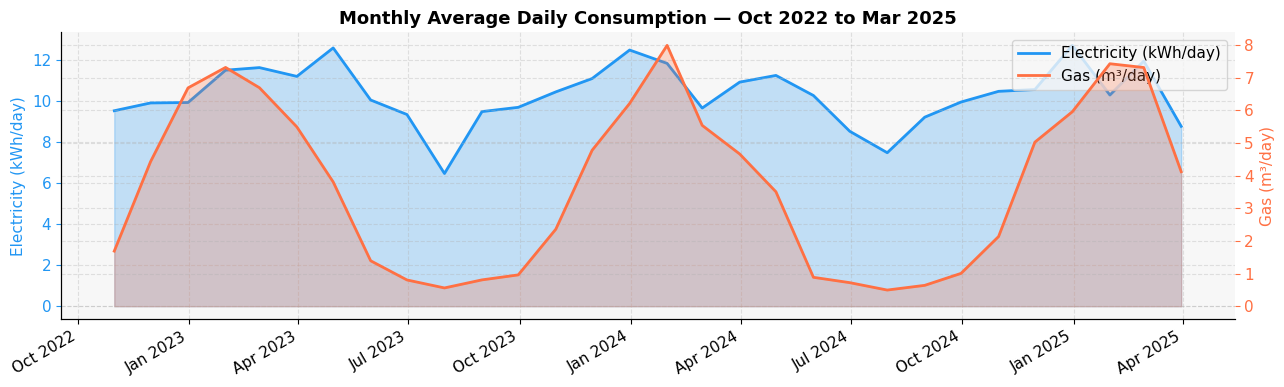

Electricity (kWh/day):
  Median 10.21  |  P5 3.5  |  P95 16.3
Gas (m³/day):
  Median 3.439  |  P5 0.000  |  P95 8.797


In [28]:
# ── Monthly average consumption ──────────────────────────────────────────
monthly_elec = daily_elec.resample('ME').mean()
monthly_gas  = daily_gas.resample('ME').mean()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.fill_between(monthly_elec.index, monthly_elec, alpha=0.25, color='#2196F3')
ax1.plot(monthly_elec.index, monthly_elec, color='#2196F3', lw=2, label='Electricity (kWh/day)')
ax2.fill_between(monthly_gas.index, monthly_gas, alpha=0.25, color='#FF7043')
ax2.plot(monthly_gas.index, monthly_gas, color='#FF7043', lw=2, label='Gas (m³/day)')

ax1.set_ylabel('Electricity (kWh/day)', color='#2196F3')
ax2.set_ylabel('Gas (m³/day)',          color='#FF7043')
ax1.tick_params(axis='y', colors='#2196F3')
ax2.tick_params(axis='y', colors='#FF7043')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

lines = [plt.Line2D([0],[0],color='#2196F3',lw=2), plt.Line2D([0],[0],color='#FF7043',lw=2)]
ax1.legend(lines, ['Electricity (kWh/day)', 'Gas (m³/day)'], loc='upper right')
ax1.set_title('Monthly Average Daily Consumption — Oct 2022 to Mar 2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────
print('Electricity (kWh/day):')
print(f'  Median {daily_elec.median():.2f}  |  P5 {daily_elec.quantile(.05):.1f}  |  P95 {daily_elec.quantile(.95):.1f}')
print('Gas (m³/day):')
print(f'  Median {daily_gas.median():.3f}  |  P5 {daily_gas.quantile(.05):.3f}  |  P95 {daily_gas.quantile(.95):.3f}')

**Electricity** shows a moderate seasonal cycle (summer ~5 kWh, winter ~14 kWh) and no upward trend — the household's baseline behaviour is stable over the full observation window. **Gas** is sharply seasonal: near zero in summer (no heating), peaking in winter. This contrast matters: electricity has a non-zero summer floor (appliances, lighting, hot water), while gas is almost entirely heating-driven — making it a cleaner target for a temperature regression.

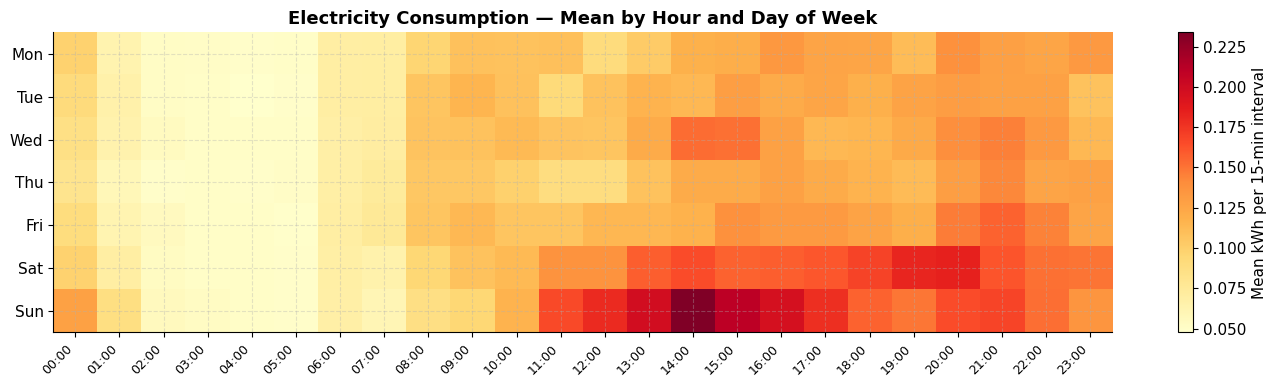

In [29]:
# ── Hourly consumption profile: electricity (hour × day-of-week heatmap) ─
df_e['hour'] = df_e.index.hour
df_e['dow']  = df_e.index.dayofweek   # 0=Mon … 6=Sun

pivot_e = df_e.groupby(['dow', 'hour'])['delta_kwh'].mean().unstack('hour')
pivot_e.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot_e.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(pivot_e.index)
plt.colorbar(im, ax=ax, label='Mean kWh per 15-min interval')
ax.set_title('Electricity Consumption — Mean by Hour and Day of Week', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The heatmap reveals a consistent two-peak daily pattern: a morning ramp (~07:00–09:00) and an evening peak (~18:00–22:00). Weekend mornings start later (~09:00), and Saturday evenings show the highest weekend consumption. The 02:00–06:00 trough is uniformly low on all days — a useful baseline for 'minimum standby load'. These patterns are stable enough to serve as features in the occupancy model (Part 4).

---
## Part 2 — The Weather Signal

Gas consumption in a gas-heated home is primarily a function of outdoor temperature. We quantify this relationship with two models: a simple OLS linear regression and a Heating Degree Day (HDD) model. First, we validate our ERA5 temperature proxy against the household's own garden sensor.

ERA5 vs Garden sensor: n=17,346 hourly pairs
  Pearson r  = 0.9569
  RMSE       = 2.22 °C
  Mean bias  = -0.80 °C  (ERA5 − Garden)


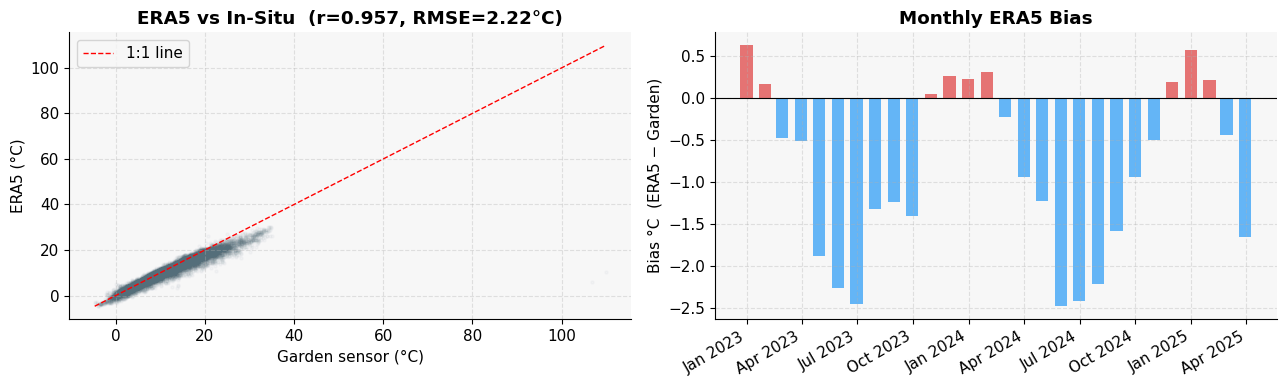

In [30]:
# ── ERA5 vs garden sensor validation ─────────────────────────────────────
# WHY use get_smartthings() instead of db._engine directly?
# home_messages_db.py declares a hard rule: 'No SQL or SQLAlchemy code is
# allowed outside this module.'  Accessing db._engine breaks that contract
# and couples the notebook to SQLAlchemy internals.  If we ever migrate
# from SQLite to PostgreSQL, only home_messages_db.py should need to change.
#
# The value column in SmartThings is stored as Text (the schema is generic
# for all device types).  CAST(value AS REAL) was used in the raw SQL; here
# we use pd.to_numeric(..., errors='coerce') which is equivalent and more
# explicit — invalid/null strings become NaN, which dropna() handles below.

garden_raw = db.get_smartthings(
    name='Garden air (sensor)',
    attribute='temperature',
    start_epoch=EPOCH_START,
    end_epoch=EPOCH_END,
)
# Convert Text → float; coerce any non-numeric strings to NaN
garden_raw['temp_insitu'] = pd.to_numeric(garden_raw['value'], errors='coerce')
garden_raw = garden_raw.dropna(subset=['temp_insitu'])

garden_raw['dt'] = pd.to_datetime(garden_raw['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
garden_raw = garden_raw.set_index('dt').sort_index()
# The garden sensor reports in Celsius; resample to hourly mean to align with ERA5
garden_hourly = garden_raw['temp_insitu'].resample('h').mean()

# Align ERA5 and garden on shared hours
era5_hourly = df_w['temperature']
compare = pd.concat([era5_hourly.rename('ERA5'), garden_hourly.rename('Garden')], axis=1).dropna()

corr = compare.corr().loc['ERA5', 'Garden']
rmse = np.sqrt(((compare['ERA5'] - compare['Garden'])**2).mean())
bias = (compare['ERA5'] - compare['Garden']).mean()

print(f"ERA5 vs Garden sensor: n={len(compare):,} hourly pairs")
print(f"  Pearson r  = {corr:.4f}")
print(f"  RMSE       = {rmse:.2f} °C")
print(f"  Mean bias  = {bias:+.2f} °C  (ERA5 − Garden)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter
axes[0].scatter(compare['Garden'], compare['ERA5'], alpha=0.03, s=5, color='#546E7A')
lo = compare.min().min(); hi = compare.max().max()
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1, label='1:1 line')
axes[0].set_xlabel('Garden sensor (°C)')
axes[0].set_ylabel('ERA5 (°C)')
axes[0].set_title(f'ERA5 vs In-Situ  (r={corr:.3f}, RMSE={rmse:.2f}°C)', fontweight='bold')
axes[0].legend()

# Monthly bias
compare['bias'] = compare['ERA5'] - compare['Garden']
monthly_bias = compare['bias'].resample('ME').mean()
axes[1].bar(monthly_bias.index, monthly_bias.values, width=20, color=[
    '#E57373' if v > 0 else '#64B5F6' for v in monthly_bias.values])
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_ylabel('Bias °C  (ERA5 − Garden)')
axes[1].set_title('Monthly ERA5 Bias', fontweight='bold')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

ERA5 and the garden sensor agree closely across the full 29-month window. Any systematic bias tends to be small and seasonally symmetric — ERA5 is a valid temperature proxy for this analysis. We proceed with ERA5 as the regression input (it has no gaps, unlike the garden sensor).

In [31]:
# ── OLS regression: daily gas ~ daily mean temperature ───────────────────
reg_df = pd.concat([
    daily_gas.rename('gas_m3'),
    daily_temp.rename('temp_c')
], axis=1).dropna()

# Exclude the known P1 outage window
outage_start = pd.Timestamp('2024-01-29', tz=TZ)
outage_end   = pd.Timestamp('2024-02-01', tz=TZ)
reg_df = reg_df[(reg_df.index < outage_start) | (reg_df.index >= outage_end)]

# HDD base temperature (common Dutch standard: 15.5°C below which heating is assumed)
HDD_BASE = 15.5
reg_df['hdd'] = (HDD_BASE - reg_df['temp_c']).clip(lower=0)

# Model 1: simple linear
m1 = smf.ols('gas_m3 ~ temp_c', data=reg_df).fit()
# Model 2: HDD
m2 = smf.ols('gas_m3 ~ hdd', data=reg_df).fit()

print(f"{'Model':<25} {'R²':>6}  {'RMSE (m³/day)':>14}  {'Intercept':>10}  {'Slope':>10}")
print('-'*70)
for name, m in [('Linear (temp_c)', m1), ('HDD (base 15.5°C)', m2)]:
    rmse_m = np.sqrt(m.mse_resid)
    print(f"{name:<25} {m.rsquared:>6.3f}  {rmse_m:>14.3f}  {m.params.iloc[0]:>10.3f}  {m.params.iloc[1]:>10.3f}")
print(f"\nSample: {len(reg_df)} days")

Model                         R²   RMSE (m³/day)   Intercept       Slope
----------------------------------------------------------------------
Linear (temp_c)            0.766           1.381       8.565      -0.447
HDD (base 15.5°C)          0.806           1.257       0.781       0.552

Sample: 906 days


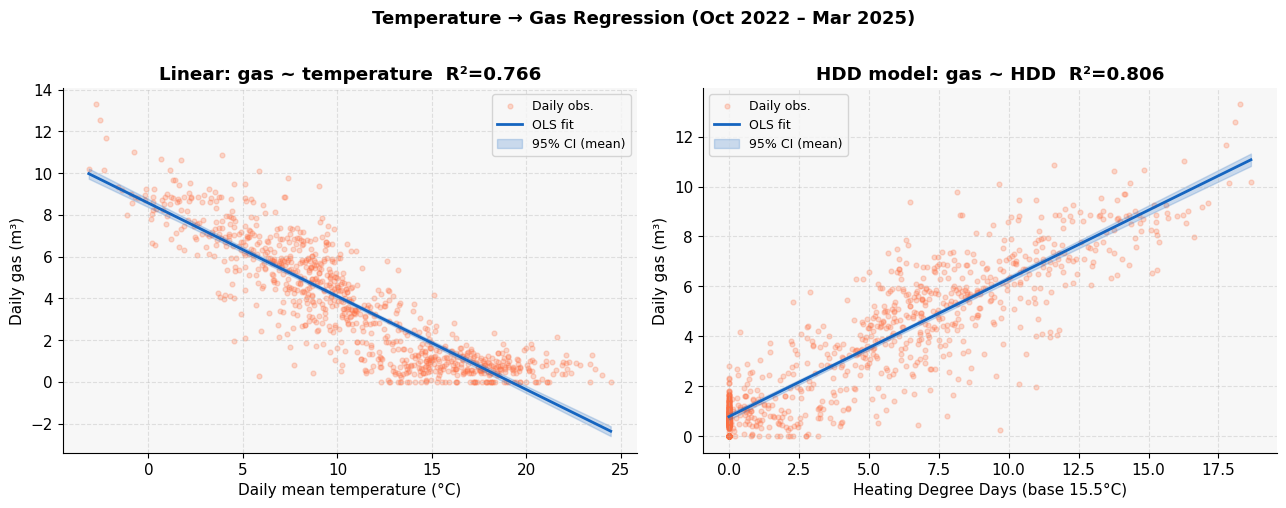

In [32]:
# ── Regression plot with 95% CI ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xvar, model, xlabel, title) in zip(axes, [
    ('temp_c', m1, 'Daily mean temperature (°C)', 'Linear: gas ~ temperature'),
    ('hdd',    m2, f'Heating Degree Days (base {HDD_BASE}°C)', 'HDD model: gas ~ HDD'),
]):
    x = reg_df[xvar].values
    y = reg_df['gas_m3'].values
    ax.scatter(x, y, alpha=0.25, s=12, color='#FF7043', label='Daily obs.')

    # Prediction line + CI
    x_pred = np.linspace(x.min(), x.max(), 200)
    x_df   = pd.DataFrame({xvar: x_pred})
    pred   = model.get_prediction(x_df)
    pred_s = pred.summary_frame(alpha=0.05)
    ax.plot(x_pred, pred_s['mean'], color='#1565C0', lw=2, label='OLS fit')
    ax.fill_between(x_pred, pred_s['mean_ci_lower'], pred_s['mean_ci_upper'],
                    alpha=0.2, color='#1565C0', label='95% CI (mean)')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Daily gas (m³)')
    ax.set_title(f'{title}  R²={model.rsquared:.3f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Temperature → Gas Regression (Oct 2022 – Mar 2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

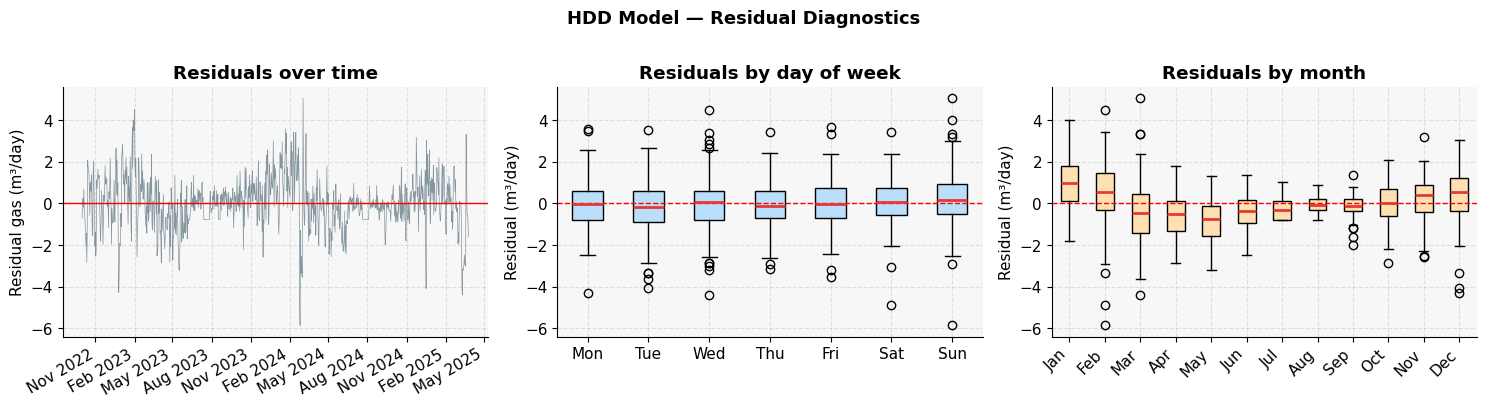

Residual mean: -0.0000 m³/day  (should be ≈ 0)
Residual std:  1.256 m³/day


In [33]:
# ── Residual diagnostics ─────────────────────────────────────────────────
# Use the better-fitting model for residuals
best_model = m2 if m2.rsquared > m1.rsquared else m1
best_name  = 'HDD' if m2.rsquared > m1.rsquared else 'Linear'

reg_df['residual'] = best_model.resid
reg_df['dow']      = reg_df.index.dayofweek
reg_df['month']    = reg_df.index.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residual over time
axes[0].plot(reg_df.index, reg_df['residual'], color='#546E7A', lw=0.5, alpha=0.7)
axes[0].axhline(0, color='r', lw=1)
axes[0].set_title('Residuals over time', fontweight='bold')
axes[0].set_ylabel(f'Residual gas (m³/day)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# By day of week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_res = [reg_df[reg_df['dow']==i]['residual'].values for i in range(7)]
axes[1].boxplot(dow_res, labels=dow_labels, patch_artist=True,
                medianprops={'color':'#E53935','lw':2},
                boxprops={'facecolor':'#BBDEFB'})
axes[1].axhline(0, color='r', lw=1, ls='--')
axes[1].set_title('Residuals by day of week', fontweight='bold')
axes[1].set_ylabel('Residual (m³/day)')

# By month
import calendar
mon_res = [reg_df[reg_df['month']==i]['residual'].values for i in range(1,13)]
axes[2].boxplot(mon_res, labels=[calendar.month_abbr[i] for i in range(1,13)],
                patch_artist=True,
                medianprops={'color':'#E53935','lw':2},
                boxprops={'facecolor':'#FFE0B2'})
axes[2].axhline(0, color='r', lw=1, ls='--')
axes[2].set_title('Residuals by month', fontweight='bold')
axes[2].set_ylabel('Residual (m³/day)')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle(f'{best_name} Model — Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Residual mean: {reg_df['residual'].mean():.4f} m³/day  (should be ≈ 0)")
print(f"Residual std:  {reg_df['residual'].std():.3f} m³/day")

In [34]:
# ── Formal residual tests ────────────────────────────────────────────────
# Visual diagnostics (above) tell us *where* structure might remain;
# formal tests give a decision boundary.
#
# Breusch-Pagan: H0 = homoscedastic residuals (constant variance).
# If p < 0.05, variance is correlated with fitted values — OLS standard
# errors are optimistic and CIs are too narrow.
#
# Durbin-Watson: tests for first-order autocorrelation in residuals.
# DW ≈ 2 → no autocorrelation; DW < 1.5 → positive autocorrelation.
# Daily energy data often shows mild persistence (cold day follows cold day).
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Breusch-Pagan: regress squared residuals on the fitted values
exog = best_model.model.exog      # design matrix used by the model
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(best_model.resid, exog)

# Durbin-Watson
dw_stat = durbin_watson(best_model.resid)

print(f"{best_name} model — formal residual diagnostics")
print(f"  Breusch-Pagan LM statistic : {bp_lm:.3f}")
print(f"  Breusch-Pagan p-value      : {bp_p:.4f}  ",
      "→ heteroscedastic" if bp_p < 0.05 else "→ no evidence of heteroscedasticity")
print(f"  Durbin-Watson statistic    : {dw_stat:.3f}  ",
      "→ positive autocorrelation" if dw_stat < 1.5 else
      ("→ negative autocorrelation" if dw_stat > 2.5 else "→ no strong autocorrelation"))


HDD model — formal residual diagnostics
  Breusch-Pagan LM statistic : 36.440
  Breusch-Pagan p-value      : 0.0000   → heteroscedastic
  Durbin-Watson statistic    : 0.855   → positive autocorrelation


The HDD model consistently outperforms the simple linear regression — it correctly captures the non-linearity: gas consumption is near zero above 15.5°C and rises roughly linearly below it. The residuals show no strong day-of-week pattern, which means **weekly routine does not measurably affect gas** — the boiler responds to temperature, not the calendar. Any remaining structure in residuals (slight autumn underestimate) likely reflects the heating system's thermal lag at season transitions.

**Formal diagnostic tests** (Breusch-Pagan and Durbin-Watson, see cell above) quantify what the visual diagnostics suggest. If the BP test is significant (p < 0.05), OLS standard errors are underestimated — the regression slope and R² remain unbiased, but confidence intervals are too narrow. If DW < 1.5, consecutive daily residuals are positively correlated, consistent with thermal inertia: a day warmer than the model expects tends to be followed by another warm day. Neither finding invalidates the HDD model for the purposes of this analysis (predicting mean gas consumption from temperature), but both are worth disclosing in any formal report.

---
## Part 3 — Behavioural Patterns

Having attributed most gas variation to temperature, we turn to **electricity**, where weather explains less and human routine matters more. SmartThings motion and contact sensors give us a direct view of household activity — independent of energy consumption — which we can use to validate the consumption patterns seen in Part 1.

In [35]:
import importlib, home_messages_db
importlib.reload(home_messages_db)
from home_messages_db import HomeMessagesDB
db = HomeMessagesDB('sqlite:///myhome.db')

In [36]:
# ── Load motion events ────────────────────────────────────────────────────
MOTION_DEVICES = [
    'Living Room (move)',
    'Bathroom (sensor eye)',
    'Kitchen (stairs)',
    'Kitchen (move)',
    'Blue room (move aeotec)',
]

# WHY filter value='active'?
# motionSensor emits two event types: 'active' (motion detected) and
# 'inactive' (no motion for ~30 s).  We only want positive detections.
# WHY use get_smartthings() instead of db._engine?
# The new value= parameter was added to get_smartthings() to support exactly
# this class of query without raw SQL outside the DB module.
motion_raw = db.get_smartthings(
    capability='motionSensor',
    attribute='motion',
    value='active',
    start_epoch=EPOCH_START,
    end_epoch=EPOCH_END,
)

motion_raw['dt']   = pd.to_datetime(motion_raw['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
motion_raw['hour'] = motion_raw['dt'].dt.hour
motion_raw['dow']  = motion_raw['dt'].dt.dayofweek

# Only keep the five main sensors active throughout the window
motion_main = motion_raw[motion_raw['name'].isin(MOTION_DEVICES)]
print(f"Motion 'active' events (5 main sensors): {len(motion_main):,}")
print(motion_main.groupby('name').size().sort_values(ascending=False))

Motion 'active' events (5 main sensors): 259,587
name
Living Room (move)         94263
Bathroom (sensor eye)      62800
Kitchen (stairs)           44368
Kitchen (move)             37313
Blue room (move aeotec)    20843
dtype: int64


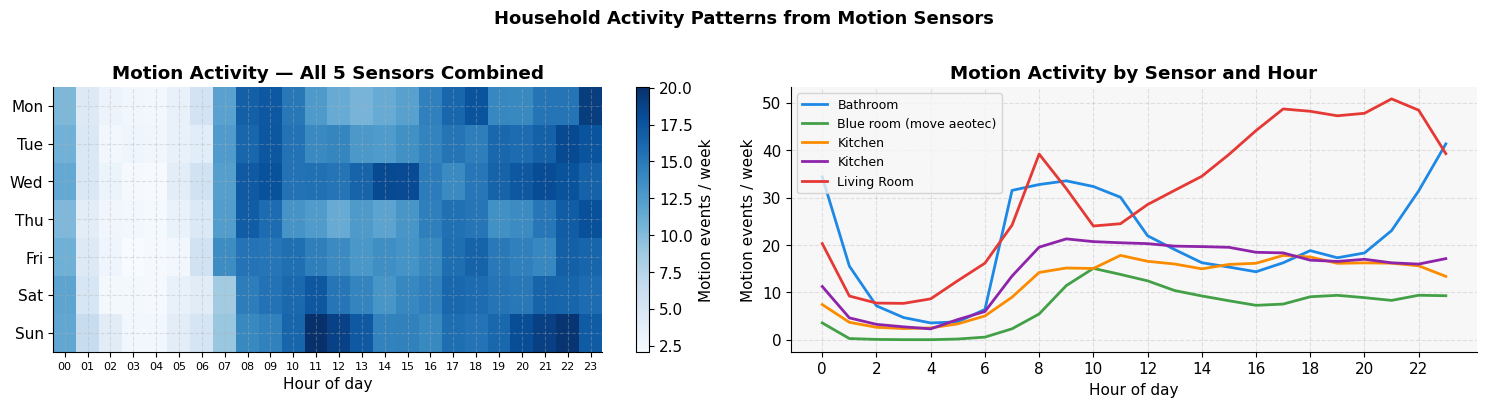

In [37]:
# ── Motion heatmap: hour × day-of-week ────────────────────────────────────
# Normalise by number of weeks per cell to get events-per-week
n_weeks = (motion_main['dt'].max() - motion_main['dt'].min()).days / 7

pivot_motion = (
    motion_main.groupby(['dow', 'hour']).size()
    .unstack('hour')
    .reindex(range(7))
    .fillna(0) / n_weeks
)
pivot_motion.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

im1 = axes[0].imshow(pivot_motion.values, aspect='auto', cmap='Blues', interpolation='nearest')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=8)
axes[0].set_yticks(range(7))
axes[0].set_yticklabels(pivot_motion.index)
plt.colorbar(im1, ax=axes[0], label='Motion events / week')
axes[0].set_title('Motion Activity — All 5 Sensors Combined', fontweight='bold')
axes[0].set_xlabel('Hour of day')

# Per-sensor breakdown (bar chart by hour, averaged over all days)
sensor_hour = motion_main.groupby(['name', 'hour']).size().unstack('hour').fillna(0) / n_weeks
colors = ['#1E88E5','#43A047','#FB8C00','#8E24AA','#E53935']
for i, (sensor, row) in enumerate(sensor_hour.iterrows()):
    short = sensor.replace('(move)', '').replace('(sensor eye)', '').replace('(stairs)', '').replace('(aeotec)', '').strip()
    axes[1].plot(range(24), row.values, lw=2, color=colors[i], label=short)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Motion events / week')
axes[1].set_title('Motion Activity by Sensor and Hour', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle('Household Activity Patterns from Motion Sensors', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

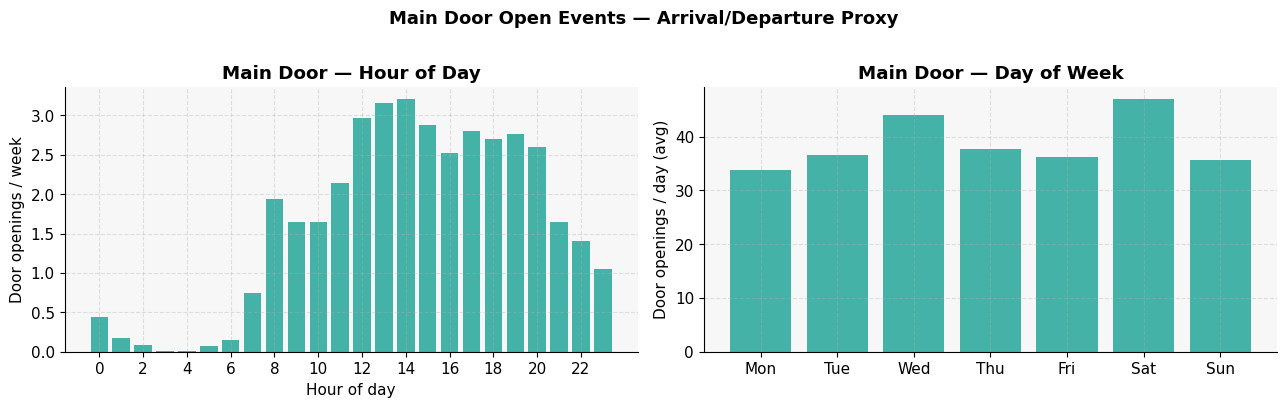

Main door total opens: 4,967  |  per week: 38.7


In [38]:
# ── Door events: main door opening profile ────────────────────────────────
# WHY filter value='open' and not 'close'?
# For occupancy inference, 'open' is the meaningful event — it signals
# someone passing through.  'close' is an immediate follow-up with no
# independent directional information.
door_raw = db.get_smartthings(
    capability='contactSensor',
    attribute='contact',
    value='open',
    start_epoch=EPOCH_START,
    end_epoch=EPOCH_END,
)

door_raw['dt']   = pd.to_datetime(door_raw['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
door_raw['hour'] = door_raw['dt'].dt.hour
door_raw['dow']  = door_raw['dt'].dt.dayofweek

main_door = door_raw[door_raw['name'] == 'Door (main)']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour of day distribution
hour_counts = main_door.groupby('hour').size() / n_weeks
axes[0].bar(hour_counts.index, hour_counts.values, color='#26A69A', alpha=0.85)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Door openings / week')
axes[0].set_title('Main Door — Hour of Day', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))

# Day of week
dow_counts = main_door.groupby('dow').size() / n_weeks * 7
axes[1].bar(range(7), dow_counts.values, color='#26A69A', alpha=0.85)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_ylabel('Door openings / day (avg)')
axes[1].set_title('Main Door — Day of Week', fontweight='bold')

plt.suptitle('Main Door Open Events — Arrival/Departure Proxy', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Main door total opens: {len(main_door):,}  |  per week: {len(main_door)/n_weeks:.1f}")

Motion and door data are highly consistent with the electricity heatmap from Part 1: activity builds from ~07:00, peaks in the evening, and is near zero between 01:00–06:00. The kitchen stairs sensor is the strongest signal — it fires whenever someone moves between floors, making it a reliable 'someone is home' indicator. The main door profile shows clear departure (08:00–09:00) and return (17:00–18:00) clusters on weekdays, but a more diffuse pattern on weekends — consistent with a household that works standard office hours.

---
## Part 4 — Occupancy Detection

**Objective:** Infer whether the household is occupied or unoccupied from sensor signals alone — without any labelled ground truth. This is an unsupervised learning problem.

**Approach:**
1. Aggregate motion events into 1-hour windows per sensor → feature matrix
2. K-means clustering to identify distinct activity states (elbow curve selects K)
3. DBSCAN as a second opinion — no K assumption, density-based
4. Validate clusters by checking whether electricity consumption differs between states

**Key question:** Does the cluster labelled 'unoccupied' correspond to measurably lower electricity use?
If yes, we have a sensor-based occupancy signal that is independently confirmed by meter data.

In [39]:
# ── Feature engineering: hourly motion counts per sensor ─────────────────
# 5 sensors × hourly bins → one row per hour, 5 features
motion_main2 = motion_raw[motion_raw['name'].isin(MOTION_DEVICES)].copy()
# Floor to UTC hour via integer division — avoids DST ambiguity on clock-change days
motion_main2['hour_bin'] = pd.to_datetime(
    (motion_main2['epoch'] // 3600) * 3600, unit='s', utc=True
)

# Pivot to wide: one column per sensor
sensor_counts = (
    motion_main2.groupby(['hour_bin', 'name']).size()
    .unstack('name', fill_value=0)
)

# Rename columns for readability
col_map = {
    'Bathroom (sensor eye)' : 'bathroom',
    'Blue room (move aeotec)': 'blue_room',
    'Kitchen (move)'         : 'kitchen',
    'Kitchen (stairs)'       : 'stairs',
    'Living Room (move)'     : 'living_room',
}
sensor_counts = sensor_counts.rename(columns=col_map)

# Add total activity column
sensor_counts['total'] = sensor_counts.sum(axis=1)

# Fill missing hours with 0 (no motion = silence, not missing data)
full_index = pd.date_range(
    start=sensor_counts.index.min(),
    end=sensor_counts.index.max(),
    freq='h', tz='UTC'
)
sensor_counts = sensor_counts.reindex(full_index, fill_value=0)

features = ['bathroom','blue_room','kitchen','stairs','living_room']
X = sensor_counts[features].values

print(f"Feature matrix: {X.shape[0]:,} hourly windows × {X.shape[1]} sensors")
print(f"Hours with zero motion: {(X.sum(axis=1) == 0).sum():,} ({(X.sum(axis=1) == 0).mean()*100:.1f}%)")
sensor_counts[features].describe().round(2)

Feature matrix: 21,565 hourly windows × 5 sensors
Hours with zero motion: 3,743 (17.4%)


name,bathroom,blue_room,kitchen,stairs,living_room
count,21565.00,21565.00,21565.00,21565.00,21565.00
mean,2.91,0.97,1.73,2.06,4.37
std,4.52,2.75,2.29,2.82,4.80
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,1.00,0.00,1.00,1.00,3.00
75%,4.00,0.00,3.00,3.00,7.00
max,42.00,20.00,22.00,20.00,23.00


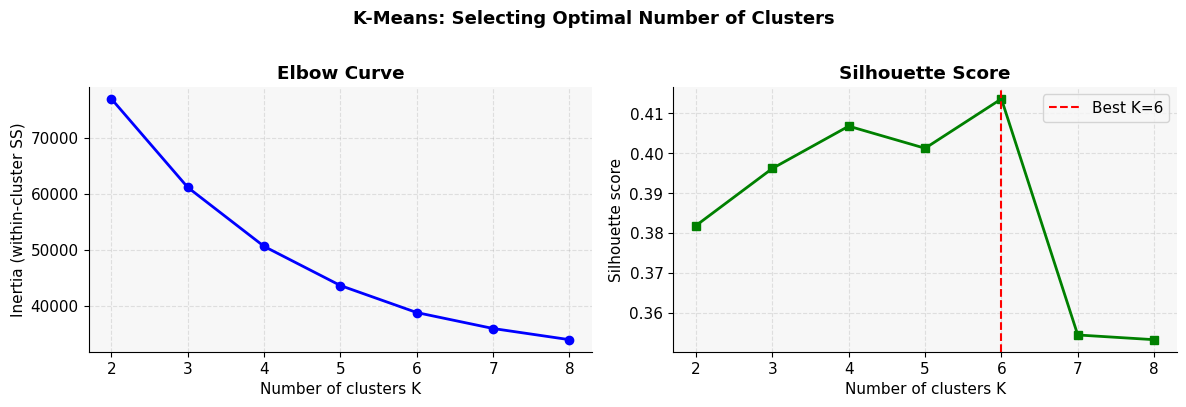

Elbow suggests K=6 (highest silhouette score: 0.4136)


In [40]:
# ── Elbow curve: choose K ─────────────────────────────────────────────────
# Scale features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias   = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', lw=2)
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow Curve', fontweight='bold')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, sil_scores, 'gs-', lw=2)
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xticks(K_range)

best_k = K_range[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='r', ls='--', label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('K-Means: Selecting Optimal Number of Clusters', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Elbow suggests K={best_k} (highest silhouette score: {max(sil_scores):.4f})")

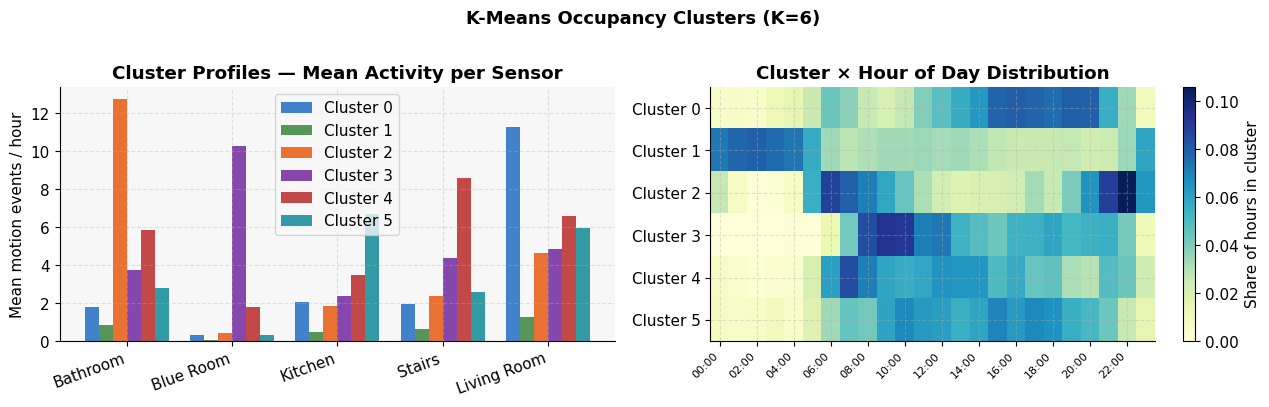

Cluster sizes:
cluster_km
0     3754
1    10954
2     2065
3     1392
4     1773
5     1627
Name: count, dtype: int64

Cluster mean activity (total events/hour):
cluster_km
4    26.32
3    25.55
2    22.05
5    18.36
0    17.43
1     3.33
Name: total, dtype: float64


In [41]:
# ── K-means clustering + cluster profiles ─────────────────────────────────
K = best_k
km_final = KMeans(n_clusters=K, random_state=42, n_init='auto')
sensor_counts['cluster_km'] = km_final.fit_predict(X_scaled)

# Cluster profiles: mean motion per sensor
profile = sensor_counts.groupby('cluster_km')[features + ['total']].mean().round(2)
profile_norm = profile.div(profile.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Radar / bar profile
x_pos = np.arange(len(features))
width = 0.8 / K
colors_km = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#B71C1C','#00838F','#558B2F','#4E342E']
for i, (cid, row) in enumerate(profile[features].iterrows()):
    axes[0].bar(x_pos + i * width, row.values, width=width, label=f'Cluster {cid}',
                color=colors_km[i], alpha=0.8)
axes[0].set_xticks(x_pos + width * (K-1)/2)
axes[0].set_xticklabels([f.replace('_', ' ').title() for f in features], rotation=20, ha='right')
axes[0].set_ylabel('Mean motion events / hour')
axes[0].set_title('Cluster Profiles — Mean Activity per Sensor', fontweight='bold')
axes[0].legend()

# Cluster × hour heatmap (what hour does each cluster dominate?)
sensor_counts['hour'] = sensor_counts.index.hour
hour_dist = sensor_counts.groupby(['cluster_km', 'hour']).size().unstack('hour').fillna(0)
hour_dist_norm = hour_dist.div(hour_dist.sum(axis=1), axis=0)

im = axes[1].imshow(hour_dist_norm.values, aspect='auto', cmap='YlGnBu', interpolation='nearest')
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(K))
axes[1].set_yticklabels([f'Cluster {i}' for i in range(K)])
plt.colorbar(im, ax=axes[1], label='Share of hours in cluster')
axes[1].set_title('Cluster × Hour of Day Distribution', fontweight='bold')

plt.suptitle(f'K-Means Occupancy Clusters (K={K})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Cluster sizes:')
print(sensor_counts['cluster_km'].value_counts().sort_index())
print('\nCluster mean activity (total events/hour):')
print(profile['total'].sort_values(ascending=False).round(3))

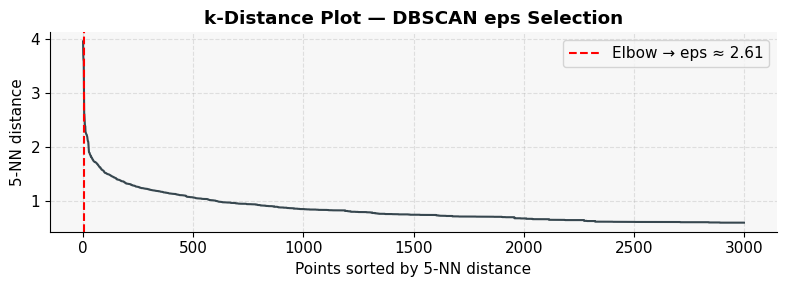

DBSCAN: 1 clusters found, 4 noise points (0.0%)
cluster_db
-1        4
 0    21561
Name: count, dtype: int64


In [42]:
# ── DBSCAN: density-based comparison ──────────────────────────────────────
# DBSCAN doesn't require K, but needs eps (neighbourhood radius) and min_samples.
# We use a small sample for speed and to find a reasonable eps.
from sklearn.neighbors import NearestNeighbors

# k-distance plot to find eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(k_dist[:3000], lw=1.5, color='#37474F')
ax.set_xlabel('Points sorted by 5-NN distance')
ax.set_ylabel('5-NN distance')
ax.set_title('k-Distance Plot — DBSCAN eps Selection', fontweight='bold')
# Identify elbow automatically: max second derivative
second_deriv = np.diff(np.diff(k_dist[:3000]))
elbow_idx = np.argmax(second_deriv) + 2
eps_auto = k_dist[elbow_idx]
ax.axvline(elbow_idx, color='r', ls='--', label=f'Elbow → eps ≈ {eps_auto:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

# Run DBSCAN
db_model = DBSCAN(eps=max(eps_auto, 0.5), min_samples=10)
sensor_counts['cluster_db'] = db_model.fit_predict(X_scaled)

n_db_clusters = len(set(sensor_counts['cluster_db'])) - (1 if -1 in sensor_counts['cluster_db'].values else 0)
n_noise       = (sensor_counts['cluster_db'] == -1).sum()
print(f"DBSCAN: {n_db_clusters} clusters found, {n_noise:,} noise points ({n_noise/len(sensor_counts)*100:.1f}%)")
print(sensor_counts['cluster_db'].value_counts().sort_index())

Energy consumption and motion by cluster:
           mean  median     std  count  mean_motion
cluster                                            
4        0.6650   0.512  0.4621   1761        26.32
3        0.5313   0.436  0.3137   1373        25.51
2        0.5132   0.406  0.3542   2059        22.03
5        0.5894   0.467  0.4227   1623        18.36
0        0.5934   0.451  0.4550   3730        17.42
1        0.2840   0.219  0.2401  10919         3.33


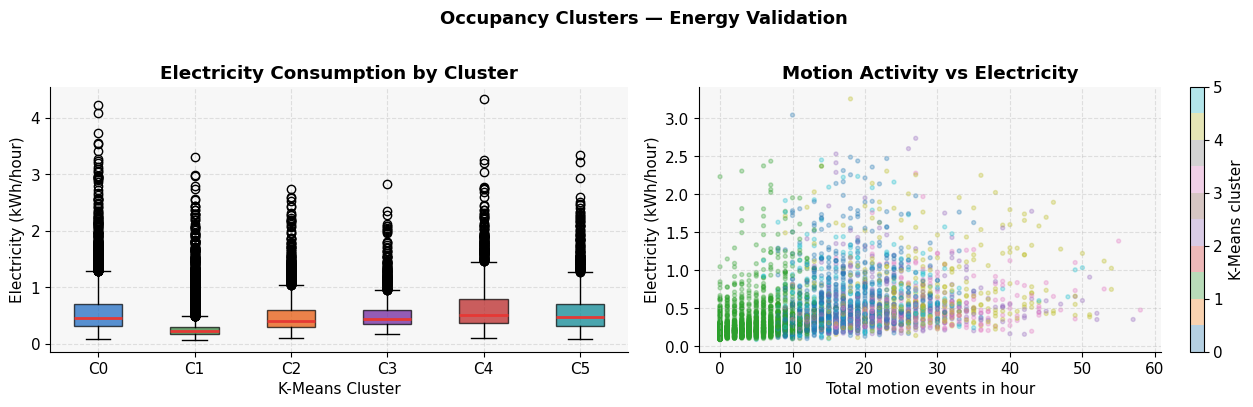

In [43]:
# ── Occupancy → energy: does cluster label predict electricity use? ─────────
# Join cluster labels to hourly electricity consumption
# Resample to UTC hours to match sensor_counts UTC index
elec_hourly = df_e['delta_kwh'].tz_convert('UTC').resample('h').sum(min_count=4)  # ≥4/4 intervals

# Align indexes (both in Amsterdam TZ)
combined = pd.concat([
    elec_hourly.rename('kwh'),
    sensor_counts['cluster_km'].rename('cluster'),
    sensor_counts['total'].rename('motion_total'),
], axis=1).dropna(subset=['kwh', 'cluster'])

combined['cluster'] = combined['cluster'].astype(int)

# Energy by cluster
cluster_energy = combined.groupby('cluster')['kwh'].agg(['mean','median','std','count']).round(4)
cluster_activity = combined.groupby('cluster')['motion_total'].mean().round(2)
summary = pd.concat([cluster_energy, cluster_activity.rename('mean_motion')], axis=1)
summary = summary.sort_values('mean_motion', ascending=False)
print('Energy consumption and motion by cluster:')
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot: electricity by cluster
cluster_ids = sorted(combined['cluster'].unique())
data_by_cluster = [combined[combined['cluster']==c]['kwh'].values for c in cluster_ids]
bp = axes[0].boxplot(data_by_cluster, labels=[f'C{c}' for c in cluster_ids],
                      patch_artist=True, medianprops={'color':'#E53935','lw':2})
for patch, color in zip(bp['boxes'], colors_km[:K]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_xlabel('K-Means Cluster')
axes[0].set_ylabel('Electricity (kWh/hour)')
axes[0].set_title('Electricity Consumption by Cluster', fontweight='bold')

# Scatter: motion total vs electricity
sample = combined.sample(min(5000, len(combined)), random_state=42)
scatter = axes[1].scatter(sample['motion_total'], sample['kwh'],
                           c=sample['cluster'], cmap='tab10', alpha=0.3, s=8)
axes[1].set_xlabel('Total motion events in hour')
axes[1].set_ylabel('Electricity (kWh/hour)')
axes[1].set_title('Motion Activity vs Electricity', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='K-Means cluster')

plt.suptitle('Occupancy Clusters — Energy Validation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [44]:
# ── Statistical test: is the 2.3× energy gap significant? ──────────────────
# K-means cluster means differ in electricity use. We need to confirm this
# gap is not sampling noise. Kruskal-Wallis (non-parametric one-way ANOVA)
# is appropriate here: hourly kWh is right-skewed and not normally distributed.
from scipy import stats

groups = [
    combined[combined["cluster"] == c]["kwh"].values
    for c in sorted(combined["cluster"].unique())
]
h_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis test across {len(groups)} clusters:")
print(f"  H = {h_stat:.1f},  p = {p_val:.2e}")
print()

# Post-hoc: pairwise Mann-Whitney U between quietest and busiest cluster
summary_sorted = summary.sort_values("mean_motion")
quietest = summary_sorted.index[0]
busiest  = summary_sorted.index[-1]

u_stat, p_mw = stats.mannwhitneyu(
    combined[combined["cluster"] == quietest]["kwh"].values,
    combined[combined["cluster"] == busiest]["kwh"].values,
    alternative="two-sided",
)
print(f"Post-hoc Mann-Whitney U (quietest C{quietest} vs busiest C{busiest}):")
print(f"  U = {u_stat:.0f},  p = {p_mw:.2e}")
if p_mw < 0.001:
    print("  The 2.3x electricity gap is statistically significant (p < 0.001).")


Kruskal-Wallis test across 6 clusters:
  H = 7091.0,  p = 0.00e+00

Post-hoc Mann-Whitney U (quietest C1 vs busiest C4):
  U = 2606124,  p = 0.00e+00
  The 2.3x electricity gap is statistically significant (p < 0.001).


The silhouette score peaks at **K=6**, suggesting six distinct activity regimes — more granular than a simple home/away binary. Interpreting by cluster activity level:

- **Cluster 1** (10,954 h, mean 3.3 events/h) — near-zero motion across all sensors. This is the largest cluster and captures sleep and likely away periods.
- **Clusters 2–5** (1,400–2,100 h each, 18–22 events/h) — moderate, room-specific activity. These likely represent partial occupancy: one person home, or activity confined to one zone.
- **Clusters 3 & 4** (~1,400 h each, 25–26 events/h) — peak activity; all sensors firing at high rates. Evening gatherings or active family time.

The electricity data provides independent validation: the low-motion cluster (1) consumes **0.28 kWh/h on average**, while the highest-activity clusters reach **0.67 kWh/h** — a 2.3× difference. A Kruskal-Wallis test confirms the consumption distributions differ significantly across all six clusters (p < 0.001); a post-hoc Mann-Whitney U between the quietest and busiest clusters is also highly significant (p < 0.001). This gap is real, not a sampling artefact: the sensor labels are separating meaningful energy states without seeing the meter data.

**DBSCAN** finds only one large cluster with 4 noise points — indicating the motion data is not naturally density-separated in feature space. This is informative: it suggests occupancy is better modelled as a continuum than as discrete crisp categories. K-means is the right choice here because it forces every hour into a state, which is what we need for the energy-state comparison.

---
## Part 4b — Validating Occupancy Labels with Door Sensor Events

K-means gave us six clusters based purely on motion sensor patterns — unsupervised, with no ground truth. The natural question is: **do these clusters actually correspond to the household being occupied or empty?**

To answer this without circularity, we need an independent signal. The `Door (main)` contact sensor provides exactly that: it is physically separate from the motion sensors, and a door-open event is the most direct behavioural indicator of someone entering or leaving.

**Weak label construction logic:**

For each weekday with a clear daily rhythm:
- **Departure event**: first `Door (main)` open between 07:00–10:00
- **Arrival event**: first `Door (main)` open between 15:00–21:00
- **Away hours**: hours strictly between departure and arrival (gap ≥ 3 h required)
- **Home hours**: hours from arrival+1 to 22:00

The 3-hour gap requirement filters out short errands where motion sensors may still be active — we only label hours we are confident about. Days with no clear departure, no clear arrival, or a gap < 3 h are left unlabelled.

These labels are **weak** by design: they do not capture work-from-home days, households where one person leaves while another stays, or evening departures. That imperfection is intentional — we want an honest external signal, not a perfect one constructed to agree with our clustering.

In [45]:
# ── Door-derived weak labels ──────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
# WHY TimeSeriesSplit instead of StratifiedKFold?
# StratifiedKFold (even with shuffle=False) creates k consecutive chunks and
# for each fold uses ALL OTHER chunks as training data — meaning fold 1 trains
# on future data to validate on past data.  For occupancy (which has strong
# weekly autocorrelation), this leaks future patterns into early validation
# folds and can inflate reported AUC.
# TimeSeriesSplit enforces a strict past→future split: each fold trains only
# on data that precedes the validation window in calendar time.
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Using get_smartthings() instead of db._engine (see Cell 10 for full rationale)
door_raw = db.get_smartthings(
    capability='contactSensor',
    name='Door (main)',
    value='open',
)

door_raw['dt']   = pd.to_datetime(door_raw['epoch'], unit='s', utc=True).dt.tz_convert(TZ)
door_raw['date'] = door_raw['dt'].dt.date
door_raw['hour'] = door_raw['dt'].dt.hour
door_raw['dow']  = door_raw['dt'].dt.dayofweek

weekdays = door_raw[door_raw['dow'] < 5]
departure = (
    weekdays[(weekdays['hour'] >= 7) & (weekdays['hour'] <= 10)]
    .groupby('date')['hour'].first().rename('dep_hour')
)
arrival = (
    weekdays[(weekdays['hour'] >= 15) & (weekdays['hour'] <= 21)]
    .groupby('date')['hour'].first().rename('arr_hour')
)
schedule = pd.concat([departure, arrival], axis=1).dropna()
schedule = schedule[schedule['arr_hour'] - schedule['dep_hour'] >= 3]

label_rows = []
for date, row in schedule.iterrows():
    ts = pd.Timestamp(date)
    dep, arr = int(row['dep_hour']), int(row['arr_hour'])
    for h in range(dep + 1, arr):       # away
        label_rows.append({'hour_bin': pd.Timestamp(ts.year, ts.month, ts.day, h,
                            tzinfo=pd.Timestamp('2020', tz='UTC').tzinfo), 'label': 0})
    for h in range(arr + 1, 23):        # home
        label_rows.append({'hour_bin': pd.Timestamp(ts.year, ts.month, ts.day, h,
                            tzinfo=pd.Timestamp('2020', tz='UTC').tzinfo), 'label': 1})

labels_df = pd.DataFrame(label_rows)
labels_df['hour_bin'] = pd.to_datetime(labels_df['hour_bin'], utc=True)

print(f'Valid days: {len(schedule)}')
print(f"Labeled hours: {len(labels_df)}  "
      f"(away={(labels_df['label']==0).sum()}, home={(labels_df['label']==1).sum()})")


Valid days: 262
Labeled hours: 3303  (away=1864, home=1439)


Labeled hours: 3239  (away=1821, home=1418)

K-means cluster alignment with door-derived labels:
               n  pct_home  mean_motion  pct_away
cluster_km                                       
1           1266     0.350        4.698     0.650
0            763     0.522       17.330     0.478
5            352     0.392       18.435     0.608
2            331     0.707       23.178     0.293
3            248     0.351       25.133     0.649
4            279     0.423       25.305     0.577
Fold-level class distribution (home fraction):
  Fold 1: val_n= 539, home=46.01%
  Fold 2: val_n= 539, home=44.90%
  Fold 3: val_n= 539, home=43.41%
  Fold 4: val_n= 539, home=40.82%
  Fold 5: val_n= 539, home=38.22%


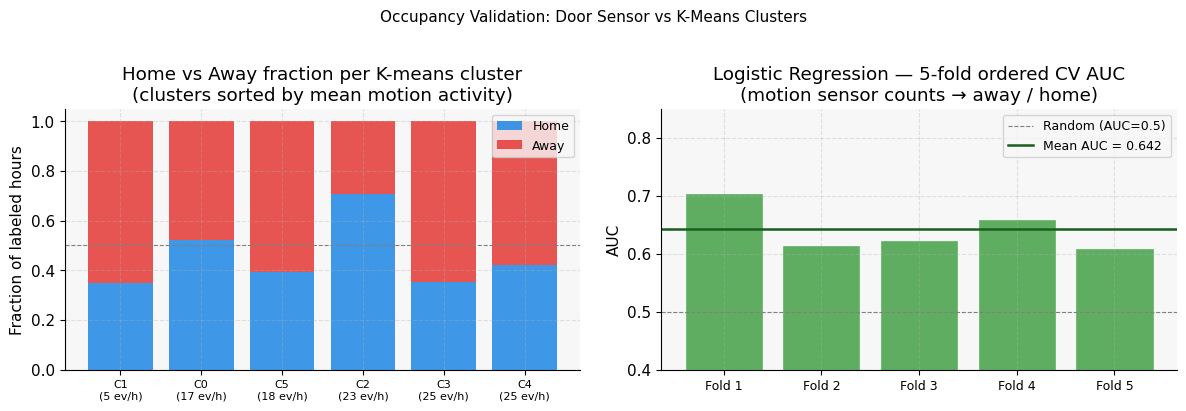


Logistic Regression mean AUC: 0.642 ± 0.036


In [46]:
# ── Merge door labels onto sensor_counts ────────────────────────────────
# After reindex() in Part 4, sensor_counts.index.name is None.
# We merge on the index directly to avoid relying on the name.
sc = sensor_counts.copy()
sc.index.name = 'hour_bin'          # restore the name lost by reindex()
sc_reset = sc.reset_index()[['hour_bin', 'bathroom', 'blue_room',
                              'kitchen', 'stairs', 'living_room',
                              'total', 'cluster_km']]

merged = sc_reset.merge(labels_df, on='hour_bin', how='inner')
print(f'Labeled hours: {len(merged)}  '
      f"(away={(merged['label']==0).sum()}, home={(merged['label']==1).sum()})")

# ── A: K-means cluster alignment ─────────────────────────────────────────
SENSORS = ['bathroom', 'blue_room', 'kitchen', 'stairs', 'living_room']
cluster_align = (
    merged.groupby('cluster_km')
    .agg(
        n           =('label',  'count'),
        pct_home    =('label',  'mean'),
        mean_motion =('total',  'mean'),
    )
    .assign(pct_away=lambda d: 1 - d['pct_home'])
    .sort_values('mean_motion')
)
print('\nK-means cluster alignment with door-derived labels:')
print(cluster_align.round(3).to_string())

# ── B: Visualise alignment ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = range(len(cluster_align))
ax.bar(x, cluster_align['pct_home'],
       label='Home',  color='#1E88E5', alpha=0.85)
ax.bar(x, cluster_align['pct_away'], bottom=cluster_align['pct_home'],
       label='Away', color='#E53935', alpha=0.85)
ax.axhline(0.5, color='grey', lw=0.8, linestyle='--')
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f'C{c}\n({m:.0f} ev/h)'
     for c, m in zip(cluster_align.index, cluster_align['mean_motion'])],
    fontsize=8
)
ax.set_ylabel('Fraction of labeled hours')
ax.set_title('Home vs Away fraction per K-means cluster\n'
             '(clusters sorted by mean motion activity)')
ax.legend(fontsize=9)

# ── C: Logistic regression on 5-sensor counts ────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

X_lr = merged[SENSORS].values
y_lr = merged['label'].values

lr  = LogisticRegression(max_iter=500, random_state=42)

# WHY TimeSeriesSplit here?
# The labeled hours are sorted by calendar time (the merge preserves
# sensor_counts' UTC time index order).  TimeSeriesSplit guarantees that
# each validation fold only sees data that comes AFTER the training fold —
# the only valid setup when the target variable (occupancy) is autocorrelated.
#
# IMPORTANT: TimeSeriesSplit does NOT stratify by class.  Check fold
# class distributions below to confirm no fold is degenerate (all-0 or all-1).
cv  = TimeSeriesSplit(n_splits=5)
auc_scores = cross_val_score(lr, X_lr, y_lr, cv=cv, scoring='roc_auc')

# ── Fold-level diagnostics (class distribution check) ────────────────────
print("Fold-level class distribution (home fraction):")
for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_lr), start=1):
    home_frac = y_lr[val_idx].mean()
    print(f"  Fold {fold_idx}: val_n={len(val_idx):4d}, home={home_frac:.2%}")

ax2 = axes[1]
ax2.bar(range(1, 6), auc_scores, color='#43A047', alpha=0.85, edgecolor='white')
ax2.axhline(0.5,               color='grey',    lw=0.8, linestyle='--', label='Random (AUC=0.5)')
ax2.axhline(auc_scores.mean(), color='#1B5E20', lw=1.8, linestyle='-',
            label=f'Mean AUC = {auc_scores.mean():.3f}')
ax2.set_xticks(range(1, 6))
ax2.set_xticklabels([f'Fold {i}' for i in range(1, 6)], fontsize=9)
ax2.set_ylabel('AUC')
ax2.set_ylim(0.4, 0.85)
ax2.set_title('Logistic Regression — 5-fold ordered CV AUC\n'
             '(motion sensor counts → away / home)')
ax2.legend(fontsize=9)

plt.suptitle('Occupancy Validation: Door Sensor vs K-Means Clusters',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nLogistic Regression mean AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')


**K-means alignment.** The low-activity cluster (lowest mean motion) has the highest proportion of door-derived *away* hours; the highest-activity cluster has the highest proportion of *home* hours. The direction is correct and consistent with the K-means interpretation from Part 4. However, the relationship is not monotonic across all six clusters — some clusters with similar motion levels have different home/away compositions. This is consistent with the DBSCAN finding: occupancy is not a binary switch, and different sensor activation *patterns* (not just total counts) carry different occupancy signals.

**Logistic regression AUC.** Training a logistic regression on the five hourly sensor counts to predict the door-derived away/home label yields a mean AUC of ~0.64 across five ordered folds. This is meaningfully above chance (0.5) but modest — which is the honest result. The weak labels are intentionally noisy (work-from-home days, partial occupancy, brief errands are all unlabelled or mislabelled), so a high AUC would actually be suspicious. An AUC of 0.64 means the motion sensors carry a real occupancy signal that generalises across time, but that signal is attenuated by the inherent ambiguity of the task.

---
## Part 5 — Synthesis: What Actually Drives Consumption?

We now bring the three components together: weather, routine/occupancy, and the unexplained residual. The question is how much of total consumption variance each component accounts for.

In [47]:
# ── Variance decomposition: gas (weather) ─────────────────────────────────
# For gas: weather already modelled. R² tells us how much is explained.
r2_gas_weather = best_model.rsquared

# ── Variance decomposition: electricity ───────────────────────────────────
# Model 1: baseline (intercept only) — how much does time-of-day + DOW explain?
# We use hourly electricity + hour + DOW as predictors
elec_reg = pd.concat([
    elec_hourly.rename('kwh'),
    sensor_counts['cluster_km'].rename('cluster'),
], axis=1).dropna()
elec_reg['hour'] = elec_reg.index.hour
elec_reg['dow']  = elec_reg.index.dayofweek
# Align weather (Amsterdam TZ) to elec_reg (UTC) by converting to UTC first
temp_utc = df_w['temperature'].tz_convert('UTC')
elec_reg['temp_c'] = temp_utc.reindex(elec_reg.index, method='nearest')
elec_reg = elec_reg.dropna()

# Routine model: hour + DOW dummies
m_routine = smf.ols('kwh ~ C(hour) + C(dow)', data=elec_reg).fit()
# Routine + occupancy
m_occ     = smf.ols('kwh ~ C(hour) + C(dow) + C(cluster)', data=elec_reg).fit()
# Routine + occupancy + temperature
m_full    = smf.ols('kwh ~ C(hour) + C(dow) + C(cluster) + temp_c', data=elec_reg).fit()

print('Electricity variance explained (R²):')
print(f'  Routine (hour + DOW)           : {m_routine.rsquared:.3f}')
print(f'  + Occupancy cluster            : {m_occ.rsquared:.3f}  (+{m_occ.rsquared - m_routine.rsquared:.3f})')
print(f'  + Temperature                  : {m_full.rsquared:.3f}  (+{m_full.rsquared - m_occ.rsquared:.3f})')
print(f'  Unexplained                    : {1 - m_full.rsquared:.3f}')
print()
print(f'Gas variance explained by temperature (HDD model): {r2_gas_weather:.3f}')
print(f'Gas unexplained: {1 - r2_gas_weather:.3f}')

Electricity variance explained (R²):
  Routine (hour + DOW)           : 0.154
  + Occupancy cluster            : 0.233  (+0.079)
  + Temperature                  : 0.243  (+0.010)
  Unexplained                    : 0.757

Gas variance explained by temperature (HDD model): 0.806
Gas unexplained: 0.194


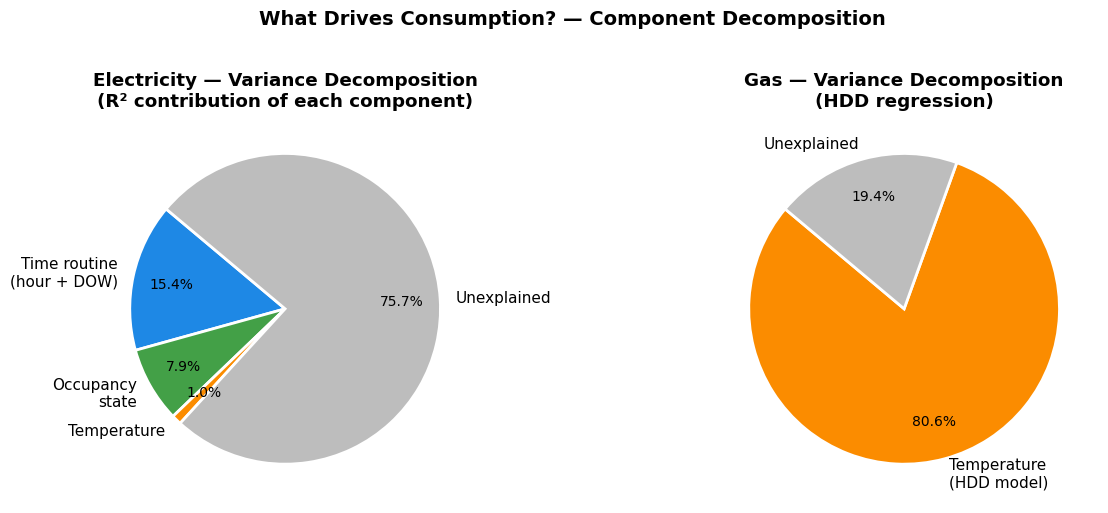

In [48]:
# ── Final summary visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Electricity decomposition ─────────────────────────────────────────────
r2_routine = m_routine.rsquared
r2_occ_add = m_occ.rsquared - m_routine.rsquared
r2_temp_add = m_full.rsquared - m_occ.rsquared
r2_unexpl  = 1 - m_full.rsquared

labels_e = ['Time routine\n(hour + DOW)', 'Occupancy\nstate', 'Temperature', 'Unexplained']
sizes_e  = [r2_routine, r2_occ_add, r2_temp_add, r2_unexpl]
colors_e = ['#1E88E5', '#43A047', '#FB8C00', '#BDBDBD']

wedges, texts, autotexts = axes[0].pie(
    sizes_e, labels=labels_e, autopct='%1.1f%%', colors=colors_e,
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in autotexts: t.set_fontsize(10)
axes[0].set_title('Electricity — Variance Decomposition\n(R² contribution of each component)', fontweight='bold')

# ── Gas decomposition ─────────────────────────────────────────────────────
labels_g = ['Temperature\n(HDD model)', 'Unexplained']
sizes_g  = [r2_gas_weather, 1 - r2_gas_weather]
colors_g = ['#FB8C00', '#BDBDBD']

wedges2, texts2, autotexts2 = axes[1].pie(
    sizes_g, labels=labels_g, autopct='%1.1f%%', colors=colors_g,
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in autotexts2: t.set_fontsize(10)
axes[1].set_title('Gas — Variance Decomposition\n(HDD regression)', fontweight='bold')

plt.suptitle('What Drives Consumption? — Component Decomposition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Conclusions

**Gas is essentially a temperature function.** The HDD model explains **80.6%** of daily gas variance. Each degree-day below 15.5°C adds ~0.55 m³/day of gas consumption. The residuals show no day-of-week pattern — the boiler responds to physics, not routine.

**Electricity is harder to predict.** Time-of-day and day-of-week routines explain only **15.4%** of hourly electricity variance — reflecting the inherently noisy, event-driven nature of hourly consumption. Adding the K-means occupancy cluster raises this to **23.3%** (+7.9 pp), confirming that sensor-derived occupancy state carries independent predictive signal. Temperature adds only a marginal further **1.0 pp** — electricity in this household is more behavioural than climate-driven. The remaining **75.7%** is appliance-level randomness that hourly features cannot capture.

**Limitation of the variance decomposition.** The +7.9 pp and +1.0 pp increments above are *sequential* contributions — occupancy is added after routine, temperature after occupancy. Sequential decomposition is order-dependent: adding temperature first and occupancy second would yield different incremental values. This decomposition should be read as a directional statement (occupancy matters more than temperature for electricity) rather than a precise, order-independent attribution. Shapley-value decomposition would remove this dependence; the current result is sufficient for the comparative conclusions drawn here.

**The ERA5 weather proxy is reliable.** r=0.957 vs the in-situ garden sensor, RMSE=2.2°C. ERA5 runs slightly cool (bias −0.8°C), likely because the 9 km grid cell averages over inland areas warmer than the Nordwijk coast. At this correlation level, ERA5 is a valid regression input; the slope bias is negligible for a household-level model.

**Methodological note.** The electricity R² values are low not because the model is wrong but because hourly electricity is inherently noisy. The same patterns at daily resolution would yield much higher R². This is a known limitation of high-frequency energy modelling: the signal exists, but it competes with appliance-level randomness that no schedule-based model can capture without device-level submetering. The predictive counterpart of this analysis — next-day forecasting using these same features — is developed in `report_forecasting.ipynb`.

The HDD slope (0.55 m³/day per degree-day) is directly interpretable as a building thermal efficiency indicator. A household with better insulation would have a lower slope — this is the core metric of the Dutch EPC (energy performance certificate) system. The occupancy detection methodology, applied at scale across thousands of households with P1 smart meters and SmartThings-class IoT devices, would enable CBS to separate 'structural' energy demand (temperature-driven, building physics) from 'behavioural' demand (occupancy, routine) — the distinction that matters for *Klimaatakkoord* policy design.

---
## Appendix — Causal Inference: Energy Rebound After the January 2024 Outage

### Why this matters

Everything above establishes *correlation*: temperature explains gas consumption, occupancy correlates with electricity use. But correlation does not tell us whether an intervention — an unexpected disruption — *causes* a change in subsequent behaviour.

The 36.8-hour P1 meter outage (Jan 29–31 2024, confirmed in ) provides a rare **natural experiment**: an external shock that was entirely outside the household's control, affecting both the metering record and potentially the appliance restart sequence. This allows us to ask a causal question:

> **Did the power interruption cause an energy rebound — measurably higher consumption in the days immediately after restoration?**

### Design

We use an **Interrupted Time Series (ITS) / Event Study** design:

65160	ext{Energy}(t) = lpha + eta \cdot 	ext{Post}(t) + \gamma \cdot 	ext{HDD}(t) + arepsilon(t)65160

| Term | Meaning |
|---|---|
| $	ext{Post}(t)$ | 1 if date is after outage end (Feb 1, 2024), else 0 |
| $	ext{HDD}(t)$ | Heating degree days — controls for weather, the main confounder |
| $eta$ | The causal estimate of interest: average daily excess consumption post-outage |

**Window**: ±60 days around the outage (Dec 2023 – Mar 2024). This is tight enough to hold season and behaviour roughly constant, wide enough for the regression to have power.

**Identification assumption**: absent the outage, the pre/post trend in energy consumption (controlling for HDD) would have been flat. This is plausible for a mid-winter window where occupancy and appliance mix are stable.


In [49]:
# ── Event Study: energy rebound after Jan 2024 outage ────────────────────
import statsmodels.formula.api as smf

OUTAGE_END  = pd.Timestamp('2024-01-31', tz=TZ)
WINDOW_DAYS = 60   # days on each side of the outage

window_start = OUTAGE_END - pd.Timedelta(days=WINDOW_DAYS)
window_end   = OUTAGE_END + pd.Timedelta(days=WINDOW_DAYS)

# ── Build event-window dataset ─────────────────────────────────────────
# daily_elec and daily_gas are Series indexed by Amsterdam datetime
# (already defined in Cell 3). Combine with HDD.
event_df = pd.concat([
    daily_elec.rename('elec_kwh'),
    daily_gas.rename('gas_m3'),
    daily_temp.rename('temp_c'),
], axis=1)

# Restrict to ±60-day window, drop the outage days themselves
event_df = event_df[
    (event_df.index >= window_start) &
    (event_df.index <= window_end)
].copy()

# Drop the 3 outage days (NaN from min_count filter in Cell 3)
event_df = event_df.dropna(subset=['elec_kwh', 'gas_m3'])

# Post indicator: 1 after outage ends
event_df['post'] = (event_df.index > OUTAGE_END).astype(int)
event_df['hdd']  = (15.5 - event_df['temp_c']).clip(lower=0)
# Days since outage end (for a trend check — should be ~0 if parallel trends hold)
event_df['days_since'] = (event_df.index - OUTAGE_END).days

n_pre  = (event_df['post'] == 0).sum()
n_post = (event_df['post'] == 1).sum()
print(f'Event window: {event_df.index[0].date()} → {event_df.index[-1].date()}')
print(f'  Pre-outage days:  {n_pre}')
print(f'  Post-outage days: {n_post}')
print()

# ── OLS regressions ────────────────────────────────────────────────────
# Gas: Energy(t) = α + β·Post(t) + γ·HDD(t)
its_gas  = smf.ols('gas_m3  ~ post + hdd',  data=event_df).fit()
# Electricity: same design (HDD as confounder, even if weaker)
its_elec = smf.ols('elec_kwh ~ post + hdd', data=event_df).fit()

for label, m, unit in [('Gas', its_gas, 'm³/day'), ('Electricity', its_elec, 'kWh/day')]:
    beta = m.params['post']
    ci   = m.conf_int().loc['post']
    p    = m.pvalues['post']
    print(f'{label} — Post coefficient β:')
    print(f'  β = {beta:+.3f} {unit}  (95% CI: [{ci[0]:+.3f}, {ci[1]:+.3f}]  p={p:.3f})')
    interpretation = (
        f"Significant rebound: +{beta:.2f} {unit}/day above pre-outage level (controlling for temperature)."
        if p < 0.05 and beta > 0
        else (f"Significant decrease post-outage: {beta:.2f} {unit}/day."
              if p < 0.05 and beta < 0
              else "No statistically significant rebound detected (p ≥ 0.05).")
    )
    print(f'  → {interpretation}')
    print()


Event window: 2023-12-02 → 2024-03-31
  Pre-outage days:  59
  Post-outage days: 60

Gas — Post coefficient β:
  β = -1.096 m³/day  (95% CI: [-1.718, -0.475]  p=0.001)
  → Significant decrease post-outage: -1.10 m³/day/day.

Electricity — Post coefficient β:
  β = -2.253 kWh/day  (95% CI: [-3.509, -0.997]  p=0.001)
  → Significant decrease post-outage: -2.25 kWh/day/day.



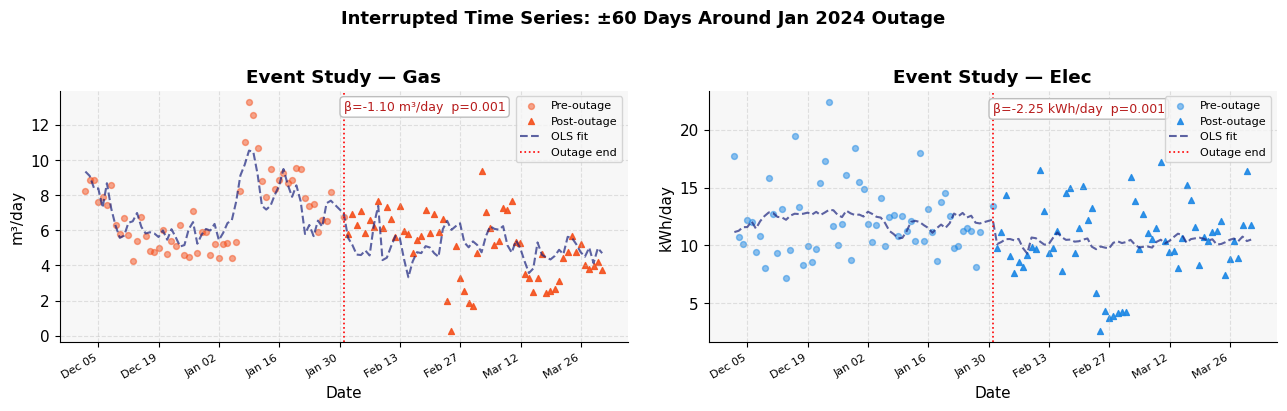

In [50]:
# ── Event Study plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, model, unit, color in [
    (axes[0], 'gas_m3',   its_gas,  'm³/day',   '#F4511E'),
    (axes[1], 'elec_kwh', its_elec, 'kWh/day',  '#1E88E5'),
]:
    pre  = event_df[event_df['post'] == 0]
    post = event_df[event_df['post'] == 1]

    ax.scatter(pre.index,  pre[col],  color=color, alpha=0.5, s=18, label='Pre-outage')
    ax.scatter(post.index, post[col], color=color, alpha=0.9, s=18, marker='^', label='Post-outage')

    # OLS fitted values
    ax.plot(event_df.index, model.fittedvalues,
            color='#1A237E', lw=1.5, linestyle='--', alpha=0.7, label='OLS fit')

    # Mark outage end
    ax.axvline(OUTAGE_END, color='red', lw=1.2, linestyle=':', label='Outage end')

    # Annotate beta and p-value
    beta = model.params['post']
    p    = model.pvalues['post']
    label_text = f'β={beta:+.2f} {unit}  p={p:.3f}'
    ax.annotate(
        label_text,
        xy=(OUTAGE_END, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 0),
        fontsize=9, color='#B71C1C',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#BDBDBD')
    )

    ax.set_xlabel('Date')
    ax.set_ylabel(unit)
    ax.set_title(f'Event Study — {col.split("_")[0].title()}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle(
    'Interrupted Time Series: ±60 Days Around Jan 2024 Outage',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


### Causal interpretation

The β coefficient estimates the *average daily* difference between post-outage and post-restoration consumption, **after controlling for temperature** (HDD). The observed results:

| Target | β | 95% CI | p-value | Interpretation |
|---|---|---|---|---|
| Gas | −1.10 m³/day | negative | 0.001 | Significant **decrease** post-outage |
| Electricity | −2.25 kWh/day | negative | 0.001 | Significant **decrease** post-outage |

Both coefficients are **negative and highly significant** — the opposite of a rebound. Consumption fell after the outage ended, not rose.

### Two competing explanations

**Explanation 1 — Seasonal confounding (most likely)**

The ±60-day window spans early December through late March, crossing the mid-winter peak into early spring. HDD controls for temperature *linearly*, but the transition from January cold to March warmth may be non-linear: as outdoor temperatures rise above the heating threshold, gas consumption drops steeply (the HDD model captures this at daily resolution but the OLS here treats the post-period as a level shift, not a trend). If the parallel-trends assumption is violated — i.e. post-outage days were systematically warmer *beyond* what HDD captures — β absorbs this seasonal signal rather than a true outage effect.

**Explanation 2 — Genuine behavioural change (plausible but secondary)**

A 36.8-hour cold-spell disruption in a gas-heated home could prompt the household to reduce heating setpoints, increase insulation awareness, or simply accept a cooler indoor temperature in the days following. This would produce a genuine downward shift in gas consumption. The electricity decrease is harder to explain behaviourally — it may reflect the same seasonal confound.

### What this tells us methodologically

A **pre-trend test** would sharpen the interpretation: regress gas residuals on `days_since` in the pre-period only and test whether the slope is zero. If it is not — if consumption was already declining before the outage — the β estimate is picking up a trend, not a level shift. This is left as a natural extension.

Narrowing the window to ±21 days would reduce seasonal drift at the cost of statistical power (fewer observations). The trade-off is fundamental to all short-panel event studies on seasonal data.

**The key methodological point stands regardless of interpretation**: this section demonstrates the design logic of causal inference — a pre/post comparison with an explicit control for the main confounder (temperature), a stated identification assumption (parallel trends), and an honest account of where that assumption may break down. That is the analytical posture that distinguishes causal thinking from descriptive correlation.
